In [ ]:
#%pip install -U albumentations opencv-python pyyaml tqdm --user

  Using cached albumentations-2.0.8-py3-none-any.whl.metadata (43 kB)
  Using cached pydantic-2.13.4-py3-none-any.whl.metadata (109 kB)
  Using cached albucore-0.0.24-py3-none-any.whl.metadata (5.3 kB)
  Using cached opencv_python_headless-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
Using cached albumentations-2.0.8-py3-none-any.whl (369 kB)
Using cached albucore-0.0.24-py3-none-any.whl (15 kB)
Using cached opencv_python_headless-4.13.0.92-cp37-abi3-win_amd64.whl (40.1 MB)
Using cached pydantic-2.13.4-py3-none-any.whl (472 kB)
Using cached annotated_types-0.7.0-py3-none-any.whl (13 kB)

   ---------------------------------------- 0/5 [opencv-python-headless]
   ---------------------------------------- 0/5 [opencv-python-headless]
   ---------------------------------------- 0/5 [opencv-python-headless]
   ---------------- ----------------------- 2/5 [pydantic]
   ---------------- ----------------------- 2/5 [p

In [ ]:
from pathlib import Path
import random
import shutil
import yaml
import cv2
import numpy as np
import albumentations as A
from tqdm import tqdm
from PIL import Image, ImageDraw
from IPython.display import display

random.seed(42)
np.random.seed(42)



RAW_ROOT = Path(r"F:\kurs_work\processed\AOD4_clean")
AUG_ROOT = Path(r"F:\kurs_work\processed\AOD4_clean_aug_light")

AUGMENT_SPLITS = ["train"]
AUG_LEVEL = "light"       
AUG_COPIES_PER_IMAGE = 1  
CLASS_NAMES = {0: "airplane", 1: "bird", 2: "drone", 3: "helicopter"}
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

BIRD_SOURCES_DIR = RAW_ROOT / "images" / "train"
BIRD_LABELS_DIR = RAW_ROOT / "labels" / "train"

In [ ]:
def get_all_images(folder: Path):
    if not folder.exists():
        return []
    return sorted(p for p in folder.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS)


def parse_yolo_label(lbl_path: Path):
    objects = []
    if not lbl_path.exists():
        return objects
    with open(lbl_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            if len(parts) == 5:
                cls, xc, yc, w, h = map(float, parts)
            elif len(parts) > 5 and (len(parts) - 1) % 2 == 0:
                cls = float(parts[0])
                coords = list(map(float, parts[1:]))
                xs = coords[0::2]
                ys = coords[1::2]
                x_min, x_max = min(xs), max(xs)
                y_min, y_max = min(ys), max(ys)
                xc = (x_min + x_max) / 2
                yc = (y_min + y_max) / 2
                w = x_max - x_min
                h = y_max - y_min
            else:
                continue
            if w <= 0 or h <= 0:
                continue
            objects.append({"class_id": int(cls), "xc": xc, "yc": yc, "w": w, "h": h})
    return objects


def write_yolo_label(lbl_path: Path, objects):
    lbl_path.parent.mkdir(parents=True, exist_ok=True)
    with open(lbl_path, "w", encoding="utf-8") as f:
        for obj in objects:
            xc = min(max(float(obj["xc"]), 0.0), 1.0)
            yc = min(max(float(obj["yc"]), 0.0), 1.0)
            w = min(max(float(obj["w"]), 0.0), 1.0)
            h = min(max(float(obj["h"]), 0.0), 1.0)
            if w <= 0 or h <= 0:
                continue
            f.write(f"{int(obj['class_id'])} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}\n")

In [ ]:


def build_pipeline(level="light"):
    light_transforms = [
        A.OneOf([
            A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25, p=1.0),
            A.HueSaturationValue(hue_shift_limit=12, sat_shift_limit=25, val_shift_limit=20, p=1.0),
        ], p=0.75),
        A.OneOf([
            A.GaussNoise(std_range=(0.02, 0.08), p=1.0),
            A.ISONoise(color_shift_range=(0.01, 0.04), intensity_range=(0.05, 0.25), p=1.0),
        ], p=0.35),
        A.Blur(blur_limit=3, p=0.15),
        A.HorizontalFlip(p=0.5),
        A.Affine(
            scale=(0.92, 1.08),
            translate_percent=(-0.04, 0.04),
            rotate=(-15, 15),
            p=0.35,
        ),
    ]

    medium_extra = [
        A.ImageCompression(quality_range=(45, 85), compression_type="jpeg", p=0.35),
        A.MotionBlur(blur_limit=(3, 5), p=0.20),
        A.RandomFog(fog_coef_range=(0.05, 0.20), alpha_coef=0.08, p=0.18),
        A.RandomRain(drop_length=12, drop_width=1, drop_color=(180, 180, 180), blur_value=3, p=0.15),
        A.RandomSnow(snow_point_range=(0.08, 0.18), brightness_coeff=1.4, p=0.12),
    ]

    hard_extra = [
        A.GaussNoise(std_range=(0.05, 0.14), p=0.35),
        A.Defocus(radius=(2, 4), alias_blur=(0.1, 0.3), p=0.20),
        A.AdvancedBlur(blur_limit=(3, 7), p=0.15),
    ]

    if level == "light":
        transforms = light_transforms
    elif level == "medium":
        transforms = light_transforms + medium_extra
    elif level == "hard":
        transforms = light_transforms + medium_extra + hard_extra
    else:
        raise ValueError("level должен быть light, medium или hard")

    return A.Compose(
        transforms,
        bbox_params=A.BboxParams(
            format="yolo",
            label_fields=["class_ids"],
            min_visibility=0.20,
            filter_invalid_bboxes=True,
        ),
    )

In [ ]:


def get_random_bird_patch(max_tries=30):
    bird_images = get_all_images(BIRD_SOURCES_DIR)
    if not bird_images:
        return None

    for _ in range(max_tries):
        src_img_path = random.choice(bird_images)
        src_lbl_path = BIRD_LABELS_DIR / f"{src_img_path.stem}.txt"
        birds = [o for o in parse_yolo_label(src_lbl_path) if o["class_id"] == 1]
        if not birds:
            continue

        image = cv2.imread(str(src_img_path))
        if image is None:
            continue
        h, w = image.shape[:2]
        bird = random.choice(birds)
        x1 = int((bird["xc"] - bird["w"] / 2) * w)
        y1 = int((bird["yc"] - bird["h"] / 2) * h)
        x2 = int((bird["xc"] + bird["w"] / 2) * w)
        y2 = int((bird["yc"] + bird["h"] / 2) * h)
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w, x2), min(h, y2)
        patch = image[y1:y2, x1:x2]
        if patch.size > 0 and patch.shape[0] >= 5 and patch.shape[1] >= 5:
            return patch
    return None


def paste_birds(image, objects, max_birds=2):
    """Добавляет птиц как класс bird. Для 4-классовой задачи это не просто фон, а обучающий пример класса bird."""
    if AUG_LEVEL != "hard":
        return image, objects

    h, w = image.shape[:2]
    result_objects = list(objects)

    for _ in range(random.randint(0, max_birds)):
        patch = get_random_bird_patch()
        if patch is None:
            continue

        scale = random.uniform(0.4, 1.1)
        new_w = max(4, int(patch.shape[1] * scale))
        new_h = max(4, int(patch.shape[0] * scale))
        if new_w >= w or new_h >= h:
            continue
        patch = cv2.resize(patch, (new_w, new_h), interpolation=cv2.INTER_AREA)

        x = random.randint(0, w - new_w)
        y = random.randint(0, h - new_h)

        # Легкое смешивание снижает резкий прямоугольный артефакт.
        alpha = random.uniform(0.65, 0.90)
        roi = image[y:y + new_h, x:x + new_w]
        image[y:y + new_h, x:x + new_w] = cv2.addWeighted(roi, 1 - alpha, patch, alpha, 0)

        result_objects.append({
            "class_id": 1,
            "xc": (x + new_w / 2) / w,
            "yc": (y + new_h / 2) / h,
            "w": new_w / w,
            "h": new_h / h,
        })

    return image, result_objects

In [ ]:


def copy_split_without_changes(split):
    shutil.copytree(RAW_ROOT / "images" / split, AUG_ROOT / "images" / split)
    shutil.copytree(RAW_ROOT / "labels" / split, AUG_ROOT / "labels" / split)


def augment_dataset():
    if AUG_ROOT.exists():
        shutil.rmtree(AUG_ROOT)

    for split in ["valid", "test"]:
        copy_split_without_changes(split)
    print("valid/test скопированы без изменений")

    pipeline = build_pipeline(AUG_LEVEL)
    stats = []

    for split in AUGMENT_SPLITS:
        out_img_dir = AUG_ROOT / "images" / split
        out_lbl_dir = AUG_ROOT / "labels" / split
        out_img_dir.mkdir(parents=True, exist_ok=True)
        out_lbl_dir.mkdir(parents=True, exist_ok=True)

        src_images = get_all_images(RAW_ROOT / "images" / split)
        counters = {"original": 0, "augmented": 0, "skipped": 0}

        for img_path in tqdm(src_images, desc=f"augment {split}"):
            lbl_path = RAW_ROOT / "labels" / split / f"{img_path.stem}.txt"
            objects = parse_yolo_label(lbl_path)

    
            shutil.copy2(img_path, out_img_dir / img_path.name)
            if lbl_path.exists():
                shutil.copy2(lbl_path, out_lbl_dir / lbl_path.name)
            else:
                (out_lbl_dir / f"{img_path.stem}.txt").touch()
            counters["original"] += 1

            image = cv2.imread(str(img_path))
            if image is None:
                counters["skipped"] += 1
                continue

            bboxes = [[o["xc"], o["yc"], o["w"], o["h"]] for o in objects]
            class_ids = [o["class_id"] for o in objects]

            for k in range(AUG_COPIES_PER_IMAGE):
                try:
                    transformed = pipeline(image=image, bboxes=bboxes, class_ids=class_ids)
                    aug_img = transformed["image"]
                    aug_bboxes = list(transformed["bboxes"])
                    aug_cls_ids = list(transformed["class_ids"])
                except Exception as e:
                    counters["skipped"] += 1
                    continue

                aug_objects = [
                    {"class_id": int(c), "xc": float(b[0]), "yc": float(b[1]), "w": float(b[2]), "h": float(b[3])}
                    for c, b in zip(aug_cls_ids, aug_bboxes)
                ]

                aug_img, aug_objects = paste_birds(aug_img, aug_objects)

                aug_name = f"{img_path.stem}_aug{k}{img_path.suffix.lower()}"
                cv2.imwrite(str(out_img_dir / aug_name), aug_img)
                write_yolo_label(out_lbl_dir / f"{Path(aug_name).stem}.txt", aug_objects)
                counters["augmented"] += 1

        stats.append({"split": split, **counters})

    with open(AUG_ROOT / "data.yaml", "w", encoding="utf-8") as f:
        yaml.safe_dump({
            "path": str(AUG_ROOT),
            "train": "images/train",
            "val": "images/valid",
            "test": "images/test",
            "names": CLASS_NAMES,
        }, f, allow_unicode=True, sort_keys=False)

    print("Готово:", AUG_ROOT)
    return stats

stats = augment_dataset()
stats

C:\Users\Иван\AppData\Local\Temp\ipykernel_18544\245555694.py:16: UserWarning: Argument(s) 'color_shift_range, intensity_range' are not valid for transform ISONoise
  A.ISONoise(color_shift_range=(0.01, 0.04), intensity_range=(0.05, 0.25), p=1.0),


valid/test скопированы без изменений


augment train: 100%|██████████| 15761/15761 [15:44<00:00, 16.69it/s]

Готово: F:\kurs_work\processed\AOD4_clean_aug_light


[{'split': 'train', 'original': 15761, 'augmented': 15761, 'skipped': 0}]

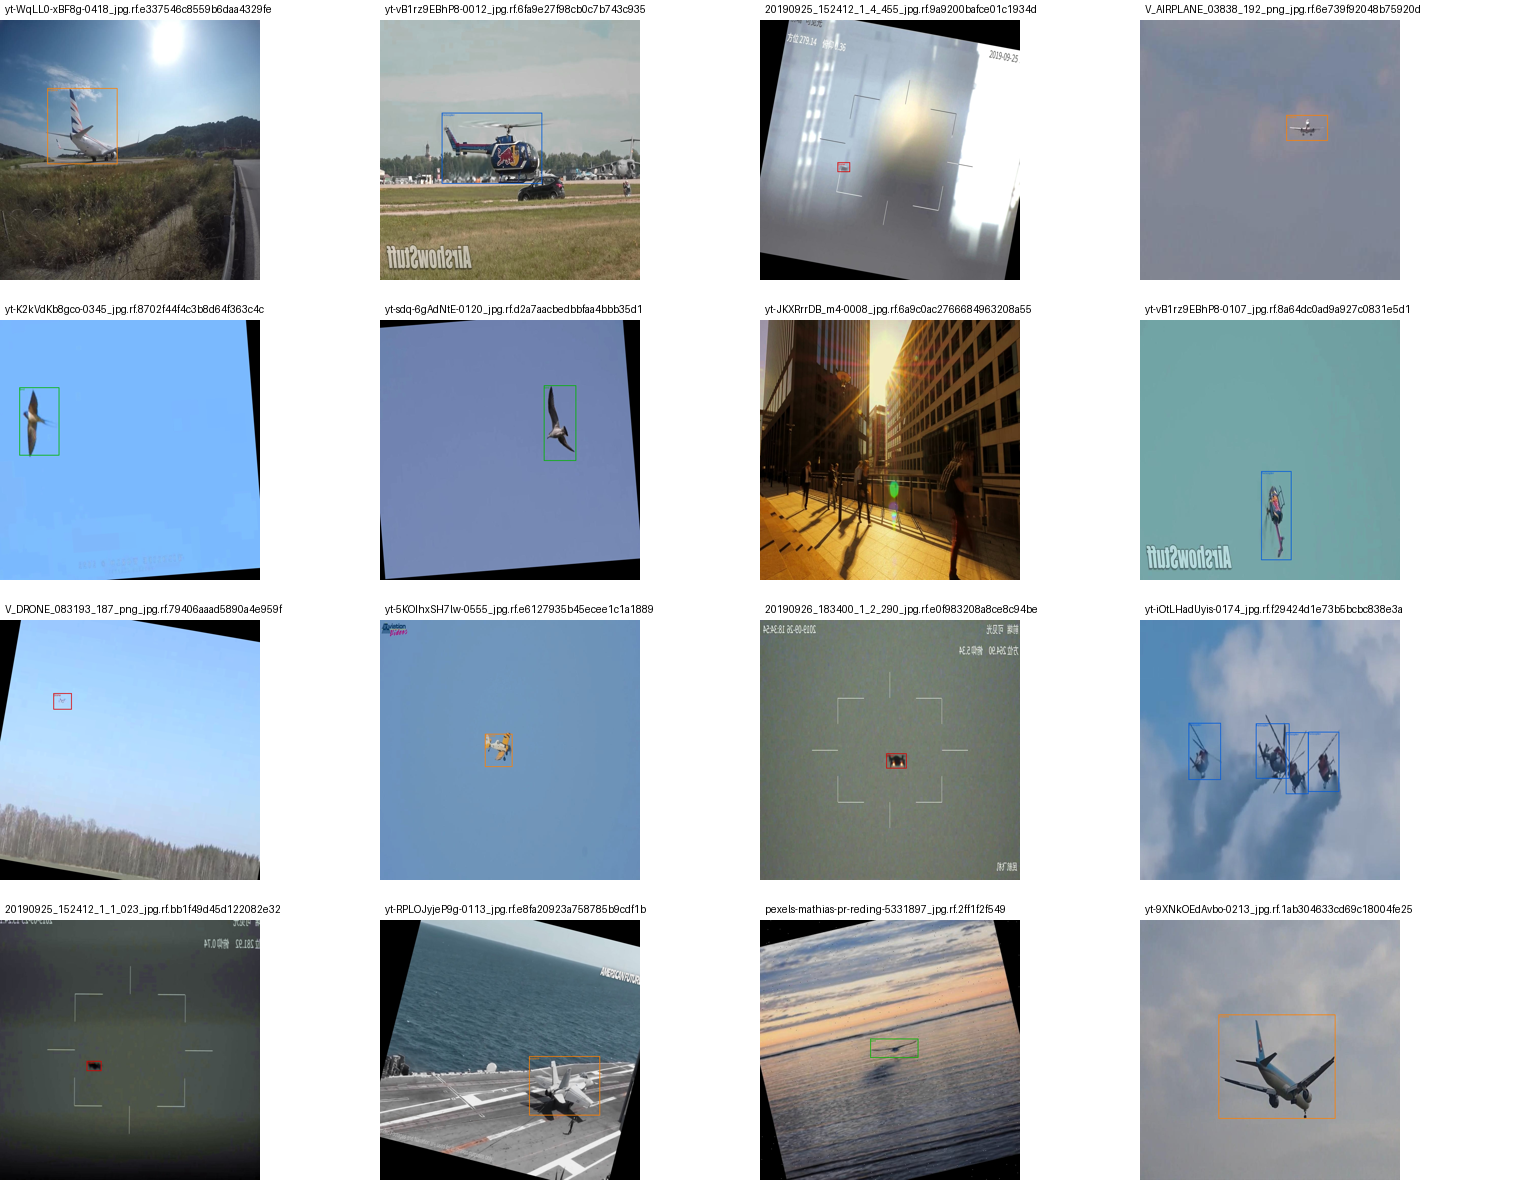

In [ ]:

CLASS_COLORS = {0: (255, 128, 0), 1: (0, 180, 0), 2: (220, 0, 0), 3: (0, 90, 220)}

def draw_boxes_pil(img_path, lbl_path, max_size=(360, 260)):
    img = Image.open(img_path).convert("RGB")
    w, h = img.size
    draw = ImageDraw.Draw(img)
    for obj in parse_yolo_label(lbl_path):
        x1 = (obj["xc"] - obj["w"] / 2) * w
        y1 = (obj["yc"] - obj["h"] / 2) * h
        x2 = (obj["xc"] + obj["w"] / 2) * w
        y2 = (obj["yc"] + obj["h"] / 2) * h
        color = CLASS_COLORS.get(obj["class_id"], (255, 0, 255))
        draw.rectangle([x1, y1, x2, y2], outline=color, width=3)
        draw.text((x1 + 2, y1 + 2), CLASS_NAMES.get(obj["class_id"], "?"), fill=color)
    img.thumbnail(max_size)
    return img

images = [p for p in get_all_images(AUG_ROOT / "images" / "train") if "_aug" in p.stem]
random.shuffle(images)
images = images[:16]
cols, cell_w, cell_h = 4, 380, 300
rows = (len(images) + cols - 1) // cols
grid = Image.new("RGB", (cols * cell_w, rows * cell_h), "white")
draw = ImageDraw.Draw(grid)

for i, img_path in enumerate(images):
    lbl_path = AUG_ROOT / "labels" / "train" / f"{img_path.stem}.txt"
    vis = draw_boxes_pil(img_path, lbl_path)
    x = (i % cols) * cell_w
    y = (i // cols) * cell_h
    grid.paste(vis, (x, y + 20))
    draw.text((x + 5, y + 3), img_path.name[:50], fill=(0, 0, 0))

display(grid)

Исходное изображение: F:\kurs_work\processed\AOD4_clean\images\train\yt-_xpX0X8Ie84-0029_jpg.rf.ffd6e157ea94a59cb3338f6de42d910c.jpg
Файл разметки: F:\kurs_work\processed\AOD4_clean\labels\train\yt-_xpX0X8Ie84-0029_jpg.rf.ffd6e157ea94a59cb3338f6de42d910c.txt
Размер исходного изображения: 1024x1024
Количество объектов: 1
Папка сохранения: F:\kurs_work\processed\augmentation_demo_original_vs_aug

Сохранены парные изображения для Word:
F:\kurs_work\processed\augmentation_demo_original_vs_aug\01_original_vs_brightness.jpg
F:\kurs_work\processed\augmentation_demo_original_vs_aug\02_original_vs_contrast.jpg
F:\kurs_work\processed\augmentation_demo_original_vs_aug\03_original_vs_horizontal_flip.jpg
F:\kurs_work\processed\augmentation_demo_original_vs_aug\04_original_vs_resize_640.jpg
F:\kurs_work\processed\augmentation_demo_original_vs_aug\05_original_vs_rotation.jpg
F:\kurs_work\processed\augmentation_demo_original_vs_aug\06_original_vs_noise.jpg
F:\kurs_work\processed\augmentation_demo_orig

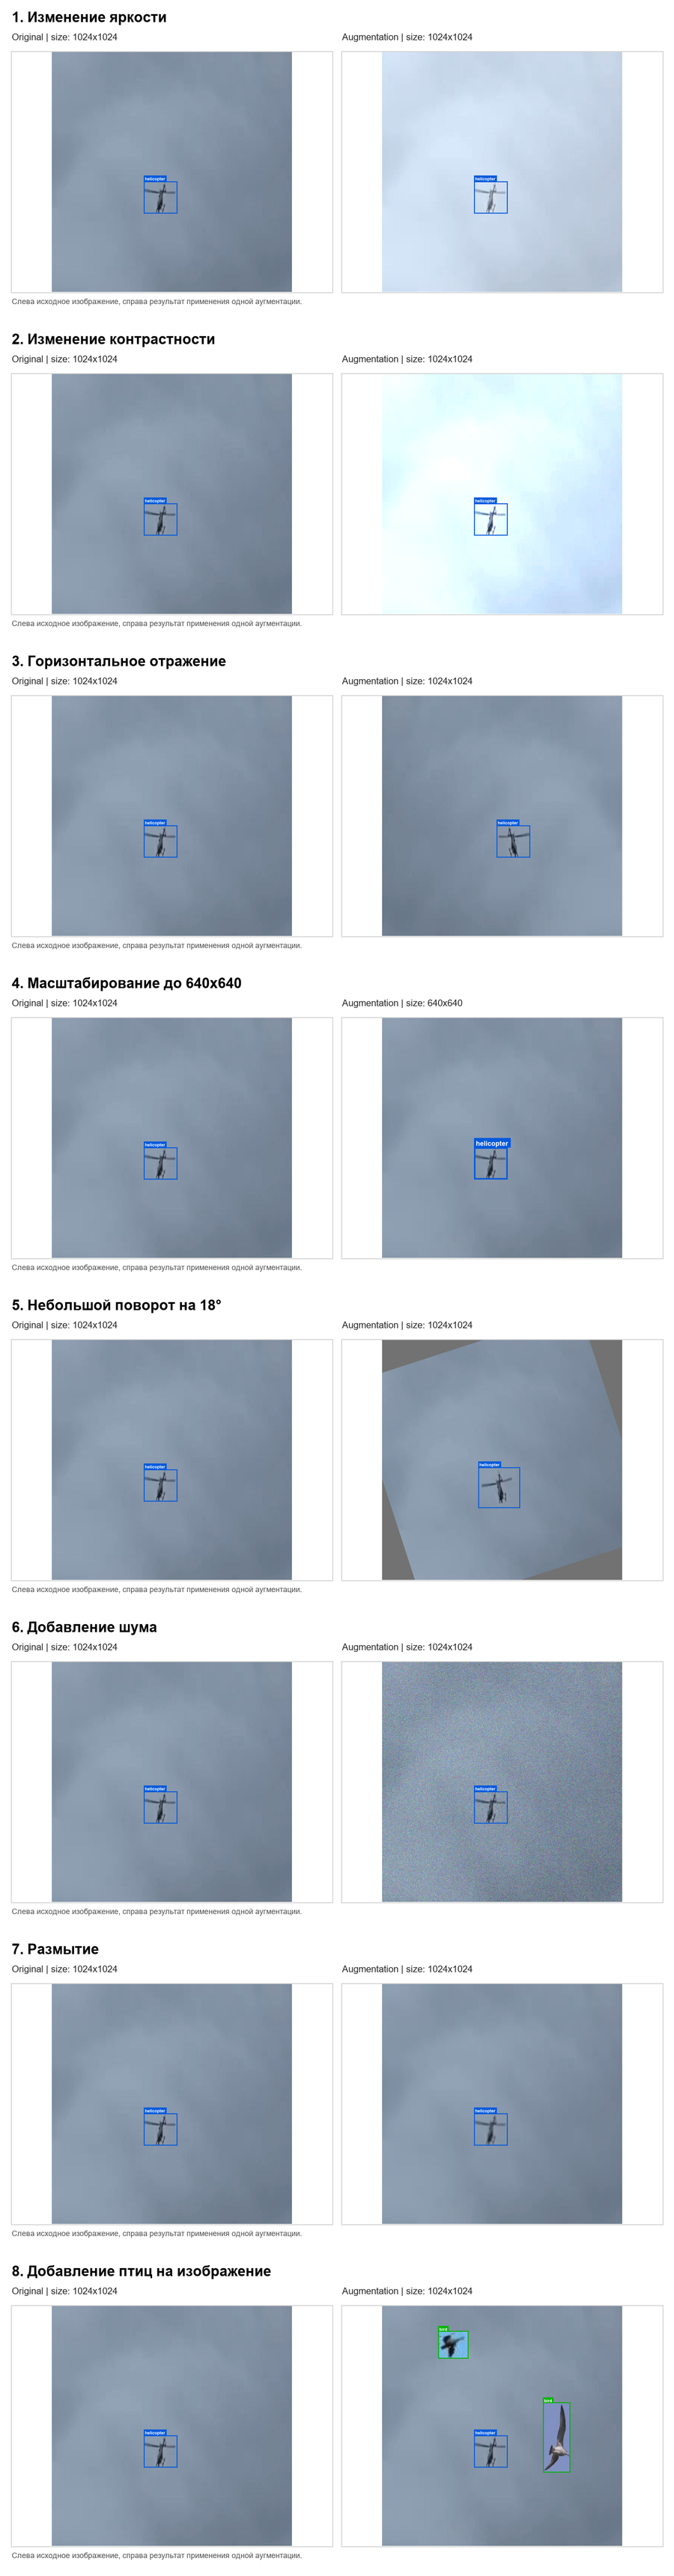

In [ ]:


from pathlib import Path
import random
import cv2
import numpy as np
import albumentations as A
from PIL import Image, ImageDraw, ImageFont, ImageFilter
from IPython.display import display


DEMO_RANDOM_SEED = 42

DEMO_IMAGE_PATH = None

if "RAW_ROOT" not in globals():
    RAW_ROOT = Path(r"F:\kurs_work\processed\AOD4_clean")

if "CLASS_NAMES" not in globals():
    CLASS_NAMES = {0: "airplane", 1: "bird", 2: "drone", 3: "helicopter"}

if "IMAGE_EXTENSIONS" not in globals():
    IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

DEMO_OUTPUT_DIR = RAW_ROOT.parent / "augmentation_demo_original_vs_aug"
DEMO_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


PAIR_PANEL_WIDTH = 760
PAIR_PANEL_HEIGHT = 570
PAIR_TOP_HEIGHT = 120
PAIR_BOTTOM_HEIGHT = 40
PAIR_GAP = 24
PAIR_MARGIN = 28
PAIR_CANVAS_WIDTH = PAIR_PANEL_WIDTH * 2 + PAIR_GAP + PAIR_MARGIN * 2
PAIR_CANVAS_HEIGHT = PAIR_TOP_HEIGHT + PAIR_PANEL_HEIGHT + PAIR_BOTTOM_HEIGHT + PAIR_MARGIN


DEMO_BRIGHTNESS_BETA = 70       # +70 к пикселям: заметно светлее
DEMO_CONTRAST_ALPHA = 1.75      # сильнее различие темного и светлого
DEMO_RESIZE_SIZE = 640          # демонстрация приведения к единому размеру
DEMO_ROTATE_DEGREES = 18        # заметный, но все еще небольшой поворот
DEMO_NOISE_STD = 36             # заметный шум
DEMO_BLUR_KERNEL = 15           # заметное размытие
DEMO_BIRD_COUNT = 2             # для наглядности вставляем две птицы, если получится

random.seed(DEMO_RANDOM_SEED)
np.random.seed(DEMO_RANDOM_SEED)

CLASS_COLORS = {
    0: (255, 128, 0),   # airplane
    1: (0, 180, 0),     # bird
    2: (220, 0, 0),     # drone
    3: (0, 90, 220),    # helicopter
}


def demo_get_font(size=24, bold=False):
    candidates = []
    if bold:
        candidates += [
            "arialbd.ttf",
            "Arial Bold.ttf",
            "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
        ]
    candidates += [
        "arial.ttf",
        "Arial.ttf",
        "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
    ]
    for name in candidates:
        try:
            return ImageFont.truetype(name, size)
        except Exception:
            pass
    return ImageFont.load_default()

FONT_TITLE = demo_get_font(34, bold=True)
FONT_SUBTITLE = demo_get_font(22, bold=False)
FONT_LABEL = demo_get_font(18, bold=True)
FONT_SMALL = demo_get_font(18, bold=False)


def demo_get_all_images(folder: Path):
    if not folder.exists():
        return []
    return sorted(p for p in folder.rglob("*") if p.suffix.lower() in IMAGE_EXTENSIONS)


def demo_label_path_for_image(img_path: Path):
    parts = list(img_path.parts)
    if "images" in parts:
        idx = parts.index("images")
        label_parts = parts.copy()
        label_parts[idx] = "labels"
        return Path(*label_parts).with_suffix(".txt")
    return img_path.with_suffix(".txt")


def demo_parse_yolo_label(lbl_path: Path):
    """
    Читает YOLO bbox. Если встретится polygon-разметка, переводит ее в bbox.
    Возвращает список объектов:
    {"class_id": int, "xc": float, "yc": float, "w": float, "h": float}
    """
    objects = []
    if not lbl_path.exists():
        return objects

    with open(lbl_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue

            try:
                if len(parts) == 5:
                    cls, xc, yc, w, h = map(float, parts)
                elif len(parts) > 5 and (len(parts) - 1) % 2 == 0:
                    cls = float(parts[0])
                    coords = list(map(float, parts[1:]))
                    xs = coords[0::2]
                    ys = coords[1::2]
                    x_min, x_max = min(xs), max(xs)
                    y_min, y_max = min(ys), max(ys)
                    xc = (x_min + x_max) / 2
                    yc = (y_min + y_max) / 2
                    w = x_max - x_min
                    h = y_max - y_min
                else:
                    continue
            except ValueError:
                continue

            if w <= 0 or h <= 0:
                continue

            objects.append({
                "class_id": int(cls),
                "xc": float(np.clip(xc, 0.0, 1.0)),
                "yc": float(np.clip(yc, 0.0, 1.0)),
                "w": float(np.clip(w, 0.0, 1.0)),
                "h": float(np.clip(h, 0.0, 1.0)),
            })

    return objects


def demo_objects_to_bboxes(objects):
    bboxes = []
    class_ids = []
    for obj in objects:
        bboxes.append([
            float(obj["xc"]),
            float(obj["yc"]),
            float(obj["w"]),
            float(obj["h"]),
        ])
        class_ids.append(int(obj["class_id"]))
    return bboxes, class_ids


def demo_bboxes_to_objects(bboxes, class_ids):
    objects = []
    for bbox, class_id in zip(bboxes, class_ids):
        if len(bbox) != 4:
            continue
        xc, yc, w, h = map(float, bbox)
        xc = float(np.clip(xc, 0.0, 1.0))
        yc = float(np.clip(yc, 0.0, 1.0))
        w = float(np.clip(w, 0.0, 1.0))
        h = float(np.clip(h, 0.0, 1.0))
        if w <= 0 or h <= 0:
            continue
        objects.append({"class_id": int(class_id), "xc": xc, "yc": yc, "w": w, "h": h})
    return objects


def demo_apply_albumentations(image, objects, transform):
    bboxes, class_ids = demo_objects_to_bboxes(objects)
    pipeline = A.Compose(
        [transform],
        bbox_params=A.BboxParams(
            format="yolo",
            label_fields=["class_ids"],
            min_visibility=0.05,
        ),
    )
    result = pipeline(image=image, bboxes=bboxes, class_ids=class_ids)
    return result["image"], demo_bboxes_to_objects(result["bboxes"], result["class_ids"])


def demo_draw_boxes(image_bgr, objects):
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    img = Image.fromarray(image_rgb)
    draw = ImageDraw.Draw(img)
    img_w, img_h = img.size

    for obj in objects:
        class_id = int(obj["class_id"])
        color = CLASS_COLORS.get(class_id, (255, 0, 255))
        name = CLASS_NAMES.get(class_id, str(class_id))

        x1 = int((obj["xc"] - obj["w"] / 2) * img_w)
        y1 = int((obj["yc"] - obj["h"] / 2) * img_h)
        x2 = int((obj["xc"] + obj["w"] / 2) * img_w)
        y2 = int((obj["yc"] + obj["h"] / 2) * img_h)

        x1 = max(0, min(x1, img_w - 1))
        y1 = max(0, min(y1, img_h - 1))
        x2 = max(0, min(x2, img_w - 1))
        y2 = max(0, min(y2, img_h - 1))

        if x2 <= x1 or y2 <= y1:
            continue

        draw.rectangle([x1, y1, x2, y2], outline=color, width=4)

        text = str(name)
        text_box = draw.textbbox((x1, y1), text, font=FONT_LABEL)
        text_w = text_box[2] - text_box[0]
        text_h = text_box[3] - text_box[1]
        label_y1 = max(0, y1 - text_h - 8)
        draw.rectangle([x1, label_y1, x1 + text_w + 10, label_y1 + text_h + 8], fill=color)
        draw.text((x1 + 5, label_y1 + 4), text, fill=(255, 255, 255), font=FONT_LABEL)

    return img


def demo_fit_to_panel(pil_img, panel_w=PAIR_PANEL_WIDTH, panel_h=PAIR_PANEL_HEIGHT):
    panel = Image.new("RGB", (panel_w, panel_h), "white")
    img = pil_img.copy()
    img.thumbnail((panel_w, panel_h), Image.Resampling.LANCZOS)
    x = (panel_w - img.width) // 2
    y = (panel_h - img.height) // 2
    panel.paste(img, (x, y))
    return panel


def demo_make_pair(original_bgr, original_objects, aug_bgr, aug_objects, aug_title, out_name):
    original_h, original_w = original_bgr.shape[:2]
    aug_h, aug_w = aug_bgr.shape[:2]

    original_vis = demo_fit_to_panel(demo_draw_boxes(original_bgr, original_objects))
    aug_vis = demo_fit_to_panel(demo_draw_boxes(aug_bgr, aug_objects))

    canvas = Image.new("RGB", (PAIR_CANVAS_WIDTH, PAIR_CANVAS_HEIGHT), "white")
    draw = ImageDraw.Draw(canvas)

    # Заголовок для всей пары.
    draw.text((PAIR_MARGIN, 18), aug_title, fill=(0, 0, 0), font=FONT_TITLE)

    left_x = PAIR_MARGIN
    right_x = PAIR_MARGIN + PAIR_PANEL_WIDTH + PAIR_GAP
    panel_y = PAIR_TOP_HEIGHT

    # Подписи над колонками.
    draw.text((left_x, 72), f"Original | size: {original_w}x{original_h}", fill=(40, 40, 40), font=FONT_SUBTITLE)
    draw.text((right_x, 72), f"Augmentation | size: {aug_w}x{aug_h}", fill=(40, 40, 40), font=FONT_SUBTITLE)

    # Рамки и панели.
    draw.rectangle(
        [left_x - 2, panel_y - 2, left_x + PAIR_PANEL_WIDTH + 2, panel_y + PAIR_PANEL_HEIGHT + 2],
        outline=(210, 210, 210),
        width=2,
    )
    draw.rectangle(
        [right_x - 2, panel_y - 2, right_x + PAIR_PANEL_WIDTH + 2, panel_y + PAIR_PANEL_HEIGHT + 2],
        outline=(210, 210, 210),
        width=2,
    )

    canvas.paste(original_vis, (left_x, panel_y))
    canvas.paste(aug_vis, (right_x, panel_y))

    bottom_y = panel_y + PAIR_PANEL_HEIGHT + 12
    draw.text((PAIR_MARGIN, bottom_y), "Слева исходное изображение, справа результат применения одной аугментации.", fill=(80, 80, 80), font=FONT_SMALL)

    out_path = DEMO_OUTPUT_DIR / f"{out_name}.jpg"
    canvas.save(out_path, quality=96)
    return out_path, canvas

def demo_find_source_image():
    if DEMO_IMAGE_PATH is not None:
        img_path = Path(DEMO_IMAGE_PATH)
        if not img_path.exists():
            raise FileNotFoundError(f"DEMO_IMAGE_PATH не найден: {img_path}")
        return img_path

    train_images = demo_get_all_images(RAW_ROOT / "images" / "train")
    if not train_images:
        raise FileNotFoundError(f"Не найдены изображения в папке: {RAW_ROOT / 'images' / 'train'}")

    images_with_labels = []
    for img_path in train_images:
        lbl_path = demo_label_path_for_image(img_path)
        objects = demo_parse_yolo_label(lbl_path)
        if objects:
            images_with_labels.append(img_path)

    if images_with_labels:
        return random.choice(images_with_labels)
    return random.choice(train_images)



def demo_find_bird_patch(max_tries=300):
    images = demo_get_all_images(RAW_ROOT / "images" / "train")
    random.shuffle(images)

    for img_path in images[:max_tries]:
        lbl_path = demo_label_path_for_image(img_path)
        objects = demo_parse_yolo_label(lbl_path)
        birds = [obj for obj in objects if obj["class_id"] == 1]
        if not birds:
            continue

        image = cv2.imread(str(img_path))
        if image is None:
            continue

        h, w = image.shape[:2]
        bird = random.choice(birds)
        x1 = int((bird["xc"] - bird["w"] / 2) * w)
        y1 = int((bird["yc"] - bird["h"] / 2) * h)
        x2 = int((bird["xc"] + bird["w"] / 2) * w)
        y2 = int((bird["yc"] + bird["h"] / 2) * h)

        x1 = max(0, min(x1, w - 1))
        y1 = max(0, min(y1, h - 1))
        x2 = max(0, min(x2, w - 1))
        y2 = max(0, min(y2, h - 1))

        if x2 <= x1 or y2 <= y1:
            continue

        patch = image[y1:y2, x1:x2].copy()
        if patch.shape[0] >= 8 and patch.shape[1] >= 8:
            return patch

    return None


def demo_paste_birds(image_bgr, objects, count=DEMO_BIRD_COUNT):
    result = image_bgr.copy()
    result_objects = list(objects)
    h, w = result.shape[:2]

    inserted = 0
    for _ in range(count):
        patch = demo_find_bird_patch()
        if patch is None:
            break

        target_w = max(18, int(w * random.uniform(0.08, 0.15)))
        scale = target_w / max(1, patch.shape[1])
        target_h = max(14, int(patch.shape[0] * scale))

        if target_w >= w or target_h >= h:
            continue

        patch = cv2.resize(patch, (target_w, target_h), interpolation=cv2.INTER_AREA)

        x = random.randint(0, w - target_w)
        y = random.randint(0, h - target_h)

        alpha = 0.90
        roi = result[y:y + target_h, x:x + target_w]
        blended = cv2.addWeighted(roi, 1.0 - alpha, patch, alpha, 0)
        result[y:y + target_h, x:x + target_w] = blended

        result_objects.append({
            "class_id": 1,
            "xc": (x + target_w / 2) / w,
            "yc": (y + target_h / 2) / h,
            "w": target_w / w,
            "h": target_h / h,
        })
        inserted += 1

    if inserted == 0:
        print("Птицы для copy-paste не найдены. Картинка для этой аугментации сохранится без вставки.")

    return result, result_objects


source_img_path = demo_find_source_image()
source_lbl_path = demo_label_path_for_image(source_img_path)

source_image = cv2.imread(str(source_img_path))
if source_image is None:
    raise ValueError(f"OpenCV не смог прочитать изображение: {source_img_path}")

source_objects = demo_parse_yolo_label(source_lbl_path)
source_h, source_w = source_image.shape[:2]

print(f"Исходное изображение: {source_img_path}")
print(f"Файл разметки: {source_lbl_path}")
print(f"Размер исходного изображения: {source_w}x{source_h}")
print(f"Количество объектов: {len(source_objects)}")
print(f"Папка сохранения: {DEMO_OUTPUT_DIR}")

saved_pairs = []
pair_previews = []

# 1. Изменение яркости — заметно светлее.
brightness_image = cv2.convertScaleAbs(source_image, alpha=1.0, beta=DEMO_BRIGHTNESS_BETA)
path, preview = demo_make_pair(
    source_image,
    source_objects,
    brightness_image,
    source_objects,
    "1. Изменение яркости",
    "01_original_vs_brightness",
)
saved_pairs.append(path)
pair_previews.append(preview)

# 2. Изменение контрастности — сильнее различие темных и светлых участков.
contrast_image = cv2.convertScaleAbs(source_image, alpha=DEMO_CONTRAST_ALPHA, beta=0)
path, preview = demo_make_pair(
    source_image,
    source_objects,
    contrast_image,
    source_objects,
    "2. Изменение контрастности",
    "02_original_vs_contrast",
)
saved_pairs.append(path)
pair_previews.append(preview)

# 3. Горизонтальное отражение.
flip_image = cv2.flip(source_image, 1)
flip_objects = []
for obj in source_objects:
    new_obj = dict(obj)
    new_obj["xc"] = 1.0 - float(obj["xc"])
    flip_objects.append(new_obj)
path, preview = demo_make_pair(
    source_image,
    source_objects,
    flip_image,
    flip_objects,
    "3. Горизонтальное отражение",
    "03_original_vs_horizontal_flip",
)
saved_pairs.append(path)
pair_previews.append(preview)

# 4. Масштабирование / приведение к единому размеру.
resize_image = cv2.resize(source_image, (DEMO_RESIZE_SIZE, DEMO_RESIZE_SIZE), interpolation=cv2.INTER_AREA)
resize_objects = list(source_objects)  # normalized YOLO bbox остаются теми же
path, preview = demo_make_pair(
    source_image,
    source_objects,
    resize_image,
    resize_objects,
    f"4. Масштабирование до {DEMO_RESIZE_SIZE}x{DEMO_RESIZE_SIZE}",
    "04_original_vs_resize_640",
)
saved_pairs.append(path)
pair_previews.append(preview)

# 5. Небольшой поворот. 
rotate_image, rotate_objects = demo_apply_albumentations(
    source_image,
    source_objects,
    A.Affine(
        scale=1.0,
        translate_percent=0.0,
        rotate=DEMO_ROTATE_DEGREES,
        border_mode=cv2.BORDER_CONSTANT,
        fill=(114, 114, 114),
        p=1.0,
    ),
)
path, preview = demo_make_pair(
    source_image,
    source_objects,
    rotate_image,
    rotate_objects,
    f"5. Небольшой поворот на {DEMO_ROTATE_DEGREES}°",
    "05_original_vs_rotation",
)
saved_pairs.append(path)
pair_previews.append(preview)

# 6. Добавление шума.
noise = np.random.normal(0, DEMO_NOISE_STD, source_image.shape).astype(np.int16)
noise_image = np.clip(source_image.astype(np.int16) + noise, 0, 255).astype(np.uint8)
path, preview = demo_make_pair(
    source_image,
    source_objects,
    noise_image,
    source_objects,
    "6. Добавление шума",
    "06_original_vs_noise",
)
saved_pairs.append(path)
pair_previews.append(preview)

# 7. Размытие.
blur_kernel = DEMO_BLUR_KERNEL
if blur_kernel % 2 == 0:
    blur_kernel += 1
blur_image = cv2.GaussianBlur(source_image, (blur_kernel, blur_kernel), 0)
path, preview = demo_make_pair(
    source_image,
    source_objects,
    blur_image,
    source_objects,
    "7. Размытие",
    "07_original_vs_blur",
)
saved_pairs.append(path)
pair_previews.append(preview)

# 8. Добавление птиц.
bird_image, bird_objects = demo_paste_birds(source_image, source_objects, count=DEMO_BIRD_COUNT)
path, preview = demo_make_pair(
    source_image,
    source_objects,
    bird_image,
    bird_objects,
    "8. Добавление птиц на изображение",
    "08_original_vs_add_birds",
)
saved_pairs.append(path)
pair_previews.append(preview)


def demo_make_preview_grid(images, cols=1):
    thumb_w = 900
    thumb_h = 430
    rows = (len(images) + cols - 1) // cols
    grid = Image.new("RGB", (cols * thumb_w, rows * thumb_h), "white")

    for i, img in enumerate(images):
        thumb = img.copy()
        thumb.thumbnail((thumb_w, thumb_h), Image.Resampling.LANCZOS)
        x = (i % cols) * thumb_w + (thumb_w - thumb.width) // 2
        y = (i // cols) * thumb_h + (thumb_h - thumb.height) // 2
        grid.paste(thumb, (x, y))

    return grid

preview_grid = demo_make_preview_grid(pair_previews, cols=1)
grid_path = DEMO_OUTPUT_DIR / "00_all_original_vs_augmentation_preview.jpg"
preview_grid.save(grid_path, quality=94)

print("\nСохранены парные изображения для Word:")
for path in saved_pairs:
    print(path)
print(f"\nОбщая сетка для просмотра: {grid_path}")

display(preview_grid)
